# Evaluating the Performance of a decision tree Model 🚀

In this notebook, we will explore the evaluation process of a **decision tree** model.

## Key Objectives 🎯:
- **Model Evaluation**: We will assess how well the decision tree model performs in terms of accuracy, precision, recall, and F1 score.
- **Performance Metrics 📊**: Using visualizations such as confusion matrices and classification reports to understand the model's strengths and areas for improvement.

Let's dive into the details and evaluate the model's performance effectively! 🔍


### includes

In [2]:

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import MinMaxScaler,LabelEncoder


### loading dataset

> Add blockquote



In [3]:
df=pd.read_csv('../../dataset/diabetes_dataset.csv')
df.head()


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [4]:
## we drop the unnessessary information
df.drop(columns=['year','location','race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other','smoking_history'],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,32.0,0,0,27.32,5.0,100,0
1,Female,29.0,0,0,19.95,5.0,90,0
2,Male,18.0,0,0,23.76,4.8,160,0
3,Male,41.0,0,0,27.32,4.0,159,0
4,Female,52.0,0,0,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...
99995,Female,33.0,0,0,21.21,6.5,90,0
99996,Female,80.0,0,0,36.66,5.7,100,0
99997,Male,46.0,0,0,36.12,6.2,158,0
99998,Female,51.0,0,0,29.29,6.0,155,0


In [5]:

encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])

label_mapping = dict(zip(encoder.classes_, range(len(encoder.classes_))))

print("Label Encoding Mapping:", label_mapping)

Label Encoding Mapping: {'Female': 0, 'Male': 1, 'Other': 2}


In [6]:
df.drop_duplicates(inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 91313 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               91313 non-null  int32  
 1   age                  91313 non-null  float64
 2   hypertension         91313 non-null  int64  
 3   heart_disease        91313 non-null  int64  
 4   bmi                  91313 non-null  float64
 5   hbA1c_level          91313 non-null  float64
 6   blood_glucose_level  91313 non-null  int64  
 7   diabetes             91313 non-null  int64  
dtypes: float64(3), int32(1), int64(4)
memory usage: 5.9 MB
None


In [7]:
## removing of missing values 
df = df.drop(df[df['gender'] == 2].index)
df.shape

(91295, 8)

In [8]:
# Select columns to normalize
cols_to_normalize = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

# Initialize scaler and apply normalization
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

print(df.tail())

       gender       age  hypertension  heart_disease       bmi  hbA1c_level  \
99995       0  0.411912             0              0  0.130719     0.545455   
99996       0  1.000000             0              0  0.311041     0.400000   
99997       1  0.574575             0              0  0.304739     0.490909   
99998       0  0.637137             0              0  0.225023     0.454545   
99999       1  0.161662             0              0  0.083450     0.272727   

       blood_glucose_level  diabetes  
99995             0.045455         0  
99996             0.090909         0  
99997             0.354545         0  
99998             0.340909         0  
99999             0.045455         0  


In [9]:
from imblearn.over_sampling import SMOTE
x=df.drop(columns=['diabetes'])
y=df['diabetes']
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(X_train['gender'])


0         1
1         0
2         0
3         1
4         1
         ..
132673    0
132674    0
132675    0
132676    0
132677    1
Name: gender, Length: 132678, dtype: int32


### tune the hyperparameters

In [10]:


# Define the model
dtree = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'ccp_alpha': [0.0, 0.01, 0.05],      # try lighter pruning
    'min_samples_leaf': [1, 5, 10],      # test slightly larger leaves
    'max_depth': [5, 10, 15],            # control tree size
    'class_weight': [None, 'balanced']   # rebalance importance of classes
}
# Setup GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,
    scoring='f1',      # or 'roc_auc' if you want to consider probability outputs
    n_jobs=-1,               # use all CPU cores
    verbose=1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best hyperparameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best hyperparameters: {'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 1}


### Train the model

In [11]:
# Best parameters found from GridSearch
best_ccp_alpha = grid_search.best_params_['ccp_alpha']
best_min_samples_leaf = grid_search.best_params_['min_samples_leaf']

# Build the final Decision Tree with best hyperparameters
final_model =DecisionTreeClassifier(class_weight='balanced',ccp_alpha= best_ccp_alpha ,  # Confidence factor equivalent for pruning
    min_samples_leaf= best_min_samples_leaf,  # Minimum samples required to be at a leaf node (minNumObj)
    random_state=42)

# Train the model on the training set
final_model.fit(X_train, y_train)

# Now the model is trained — you can evaluate it on the test set!
best_min_samples_leaf

1

### Test the model

In [12]:
y_pred = final_model.predict(X_test)

# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')  # change 'binary' to 'macro' if multi-class
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Alternatively, full detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm=confusion_matrix(y_test, y_pred)

Accuracy: 0.9392
Precision: 0.6656
Recall: 0.7327
F1-score: 0.6975

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97     16512
           1       0.67      0.73      0.70      1747

    accuracy                           0.94     18259
   macro avg       0.82      0.85      0.83     18259
weighted avg       0.94      0.94      0.94     18259


Confusion Matrix:
 [[15869   643]
 [  467  1280]]


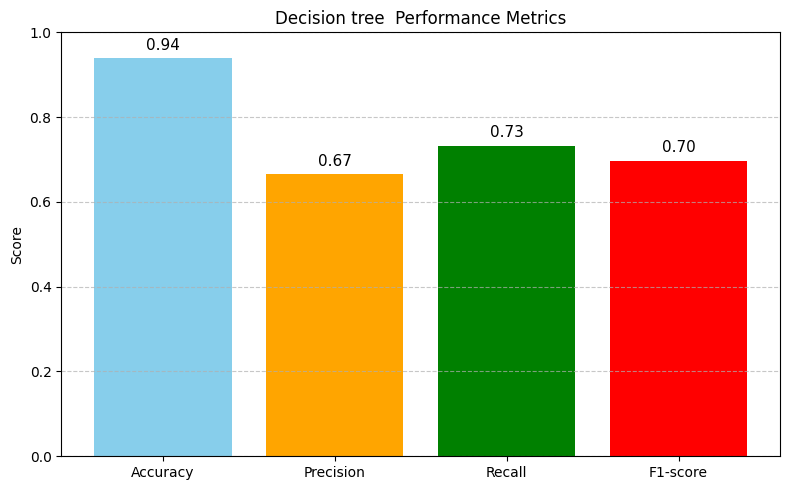

In [ ]:

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}
# Plotting the histogram
plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color=['skyblue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.title('Decision tree  Performance Metrics')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotating the bars with values
for i, (key, value) in enumerate(metrics.items()):
    plt.text(i, value + 0.02, f"{value:.2f}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

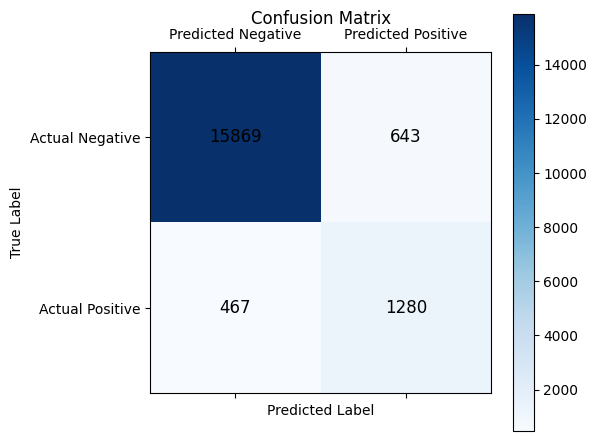

In [13]:


# Labels
labels = ['Predicted Negative', 'Predicted Positive']
categories = ['Actual Negative', 'Actual Positive']

# Plotting
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(cm, cmap='Blues')

# Annotate each cell
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, f'{val}', ha='center', va='center', fontsize=12)

# Set axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(categories)

plt.title("Confusion Matrix", pad=20)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
fig.colorbar(cax)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import roc_auc_score, f1_score

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))


F1 Score: 0.6975476839237057
ROC AUC Score: 0.8477290145509688


In [15]:
import numpy as np
np.unique(y_pred, return_counts=True)

(array([0, 1], dtype=int64), array([16336,  1923], dtype=int64))